### **Decision Tree Classifier for Social_Network_Ads Dataset**

##### **Data PreProcessing**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv(r"D:\261100670031\AML_LAB\LAB\Data\Social_Network_Ads.csv" )
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [3]:
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [4]:
df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [6]:
df.dtypes

User ID            int64
Gender               str
Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object

In [7]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [8]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
# X=dataset.iloc[:,[2,3]].values
# y=dataset.iloc[:,4].values

X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Age  EstimatedSalary
0   19            19000
1   35            20000
2   26            43000
3   27            57000
4   19            76000

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64


In [12]:
#
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.25,random_state=0
)
print("X_train:")
print(X_train.head())

print("\nX_test:")
print(X_test.head())

print("\nTraining data size:", X_train.shape)
print("Testing data size:", X_test.shape)

X_train:
     Age  EstimatedSalary
250   44            39000
63    32           120000
312   38            50000
159   32           135000
283   52            21000

X_test:
     Age  EstimatedSalary
132   30            87000
309   38            50000
341   35            75000
196   30            79000
246   35            50000

Training data size: (300, 2)
Testing data size: (100, 2)


In [13]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
X_test

array([[-0.80480212,  0.50496393],
       [-0.01254409, -0.5677824 ],
       [-0.30964085,  0.1570462 ],
       [-0.80480212,  0.27301877],
       [-0.30964085, -0.5677824 ],
       [-1.10189888, -1.43757673],
       [-0.70576986, -1.58254245],
       [-0.21060859,  2.15757314],
       [-1.99318916, -0.04590581],
       [ 0.8787462 , -0.77073441],
       [-0.80480212, -0.59677555],
       [-1.00286662, -0.42281668],
       [-0.11157634, -0.42281668],
       [ 0.08648817,  0.21503249],
       [-1.79512465,  0.47597078],
       [-0.60673761,  1.37475825],
       [-0.11157634,  0.21503249],
       [-1.89415691,  0.44697764],
       [ 1.67100423,  1.75166912],
       [-0.30964085, -1.37959044],
       [-0.30964085, -0.65476184],
       [ 0.8787462 ,  2.15757314],
       [ 0.28455268, -0.53878926],
       [ 0.8787462 ,  1.02684052],
       [-1.49802789, -1.20563157],
       [ 1.07681071,  2.07059371],
       [-1.00286662,  0.50496393],
       [-0.90383437,  0.30201192],
       [-0.11157634,

---

##### **Entropy**

In [14]:
#Fitting Decision Tree Classification to Training Set
from sklearn.tree import DecisionTreeClassifier
classifier= DecisionTreeClassifier(criterion='entropy',random_state=0)
#classifier= DecisionTreeClassifier(criterion='gini',random_state=0)
classifier.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [15]:
# Predicting the Test Set results
y_pred = classifier.predict(X_test)

print("Predicted values:")
print(y_pred)

print("Actual values:")
print(y_test.values)

Predicted values:
[0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 1 0 0 1
 0 0 0 0 1 1 1 1 0 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 1 1]
Actual values:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1]


In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[62  6]
 [ 3 29]]


In [17]:
Accuracy=(cm[0][0]+cm[1][1])/(cm[0][0]+cm[0][1]+cm[1][0]+cm[1][1])
Accuracy

np.float64(0.91)

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.91


In [19]:
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculate
#Model Accuracy, how often is the classifier correct?
prediction=metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", prediction*100,'%')

Accuracy: 91.0 %


In [20]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93        68
           1       0.83      0.91      0.87        32

    accuracy                           0.91       100
   macro avg       0.89      0.91      0.90       100
weighted avg       0.91      0.91      0.91       100



In [21]:
# Predict for a new individual with Age = 29 and Estimated Salary
new_individual = np.array([[29,80000]])

# Scale the new individual's features
new_individual_scaled =sc.transform(new_individual)

#Predict using the trained classifier
prediction=classifier.predict(new_individual_scaled)

if prediction[0] == 1:
    print("The individual is predicted to purchase.")
else:
    print("The individual is predicted not to purchase.")

The individual is predicted not to purchase.


c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Text(0.4967948717948718, 0.9615384615384616, 'x[0] <= 0.631\nentropy = 0.951\nsamples = 300\nvalue = [189, 111]'),
 Text(0.26282051282051283, 0.8846153846153846, 'x[1] <= 0.606\nentropy = 0.693\nsamples = 215\nvalue = [175, 40]'),
 Text(0.3798076923076923, 0.9230769230769231, 'True  '),
 Text(0.11538461538461539, 0.8076923076923077, 'x[0] <= -0.161\nentropy = 0.241\nsamples = 176\nvalue = [169, 7]'),
 Text(0.08974358974358974, 0.7307692307692307, 'entropy = 0.0\nsamples = 114\nvalue = [114, 0]'),
 Text(0.14102564102564102, 0.7307692307692307, 'x[1] <= -0.06\nentropy = 0.509\nsamples = 62\nvalue = [55, 7]'),
 Text(0.11538461538461539, 0.6538461538461539, 'entropy = 0.0\nsamples = 31\nvalue = [31, 0]'),
 Text(0.16666666666666666, 0.6538461538461539, 'x[1] <= 0.403\nentropy = 0.771\nsamples = 31\nvalue = [24, 7]'),
 Text(0.14102564102564102, 0.5769230769230769, 'x[1] <= 0.027\nentropy = 0.663\nsamples = 29\nvalue = [24, 5]'),
 Text(0.11538461538461539, 0.5, 'entropy = 0.0\nsamples = 1\nv

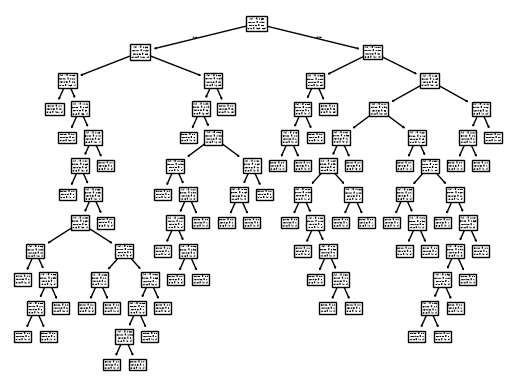

In [22]:
from sklearn import tree
tree.plot_tree(classifier)

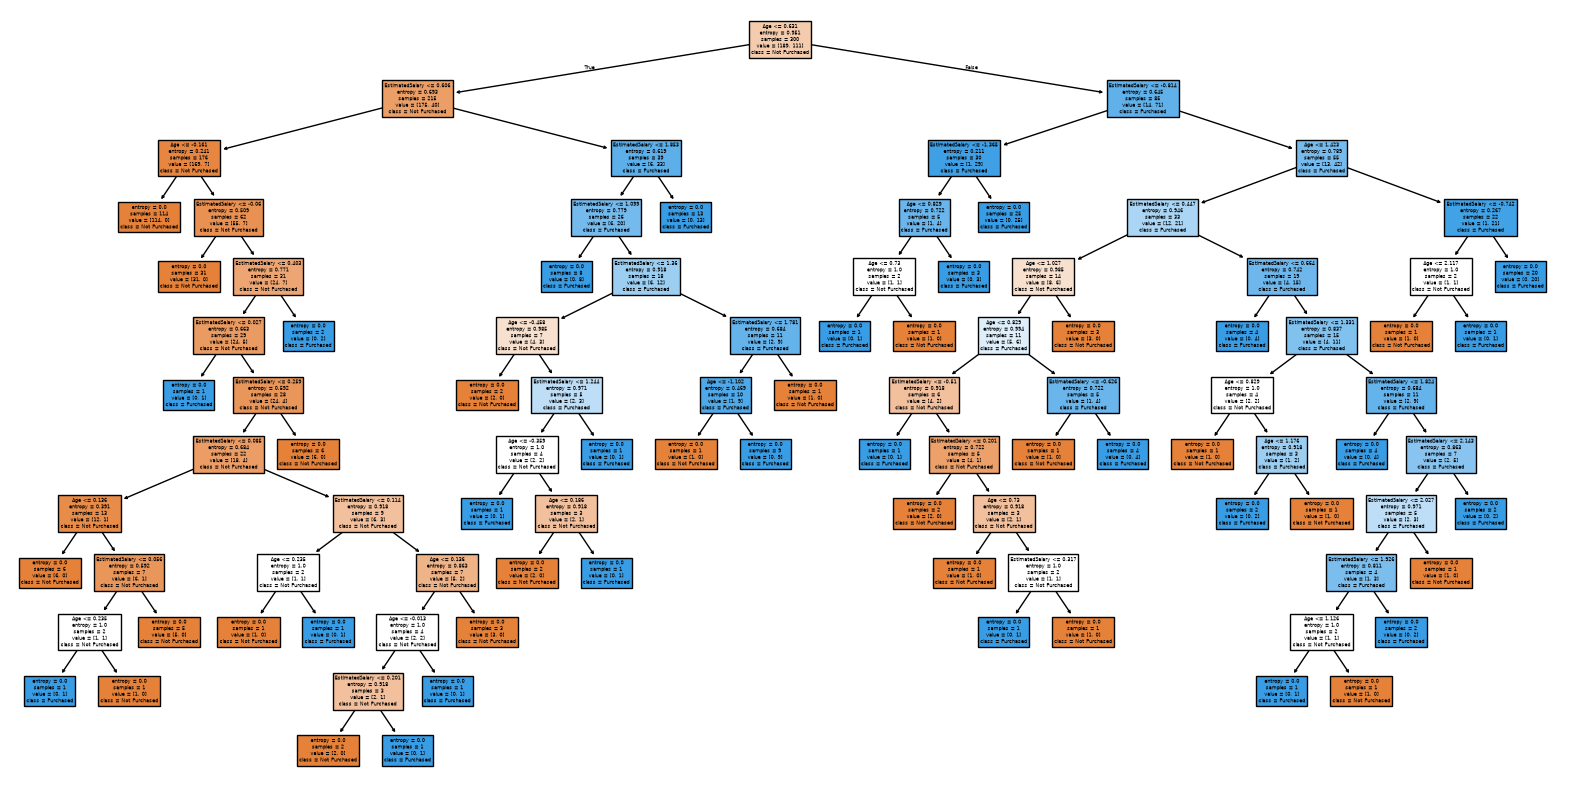

In [23]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

tree.plot_tree(
    classifier,
    feature_names=["Age", "EstimatedSalary"],
    class_names=["Not Purchased", "Purchased"],
    filled=True
)

plt.show()

---

##### **Gini**

In [24]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(criterion='gini', random_state=0)

classifier.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [25]:
# Predicting the Test Set results
y_pred = classifier.predict(X_test)

print("Predicted values:")
print(y_pred)

print("Actual values:")
print(y_test.values)

Predicted values:
[0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 1 0 0 1
 0 0 0 0 1 1 1 1 0 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 1 1]
Actual values:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1]


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[62  6]
 [ 4 28]]


In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9


In [28]:
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculate
#Model Accuracy, how often is the classifier correct?
prediction=metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", prediction*100,'%')

Accuracy: 90.0 %


In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93        68
           1       0.82      0.88      0.85        32

    accuracy                           0.90       100
   macro avg       0.88      0.89      0.89       100
weighted avg       0.90      0.90      0.90       100



In [30]:
# Predict for a new individual with Age = 30 and Estimated Salary
new_individual = np.array([[30,95000]])

# Scale the new individual's features
new_individual_scaled =sc.transform(new_individual)

#Predict using the trained classifier
prediction=classifier.predict(new_individual_scaled)

if prediction[0] == 1:
    print("The individual is predicted to purchase.")
else:
    print("The individual is predicted not to purchase.")

The individual is predicted to purchase.


c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [31]:
# Predict for a new individual with Age = 29 and Estimated Salary
new_individual = np.array([[29,80000]])

# Scale the new individual's features
new_individual_scaled =sc.transform(new_individual)

#Predict using the trained classifier
prediction=classifier.predict(new_individual_scaled)

if prediction[0] == 1:
    print("The individual is predicted to purchase.")
else:
    print("The individual is predicted not to purchase.")

The individual is predicted not to purchase.


c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Text(0.4519230769230769, 0.9615384615384616, 'x[0] <= 0.631\ngini = 0.466\nsamples = 300\nvalue = [189, 111]'),
 Text(0.22435897435897437, 0.8846153846153846, 'x[1] <= 0.606\ngini = 0.303\nsamples = 215\nvalue = [175, 40]'),
 Text(0.33814102564102566, 0.9230769230769231, 'True  '),
 Text(0.11538461538461539, 0.8076923076923077, 'x[0] <= -0.161\ngini = 0.076\nsamples = 176\nvalue = [169, 7]'),
 Text(0.08974358974358974, 0.7307692307692307, 'gini = 0.0\nsamples = 114\nvalue = [114, 0]'),
 Text(0.14102564102564102, 0.7307692307692307, 'x[1] <= 0.403\ngini = 0.2\nsamples = 62\nvalue = [55, 7]'),
 Text(0.11538461538461539, 0.6538461538461539, 'x[1] <= -0.06\ngini = 0.153\nsamples = 60\nvalue = [55, 5]'),
 Text(0.08974358974358974, 0.5769230769230769, 'gini = 0.0\nsamples = 31\nvalue = [31, 0]'),
 Text(0.14102564102564102, 0.5769230769230769, 'x[1] <= 0.027\ngini = 0.285\nsamples = 29\nvalue = [24, 5]'),
 Text(0.11538461538461539, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.166

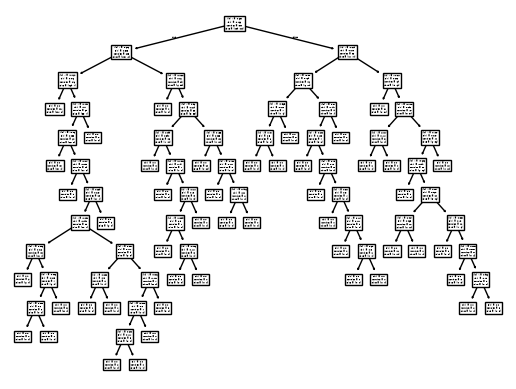

In [32]:
from sklearn import tree
tree.plot_tree(classifier)

---

##### **Compare with different Test Size**

In [33]:

# Test sizes to compare
test_sizes = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

results = []

for test_size in test_sizes:

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=0
    )

    # Scaling
    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_test = sc.transform(X_test)

    # Entropy
    entropy_classifier = DecisionTreeClassifier(
        criterion="entropy",
        random_state=0
    )

    entropy_classifier.fit(X_train, y_train)
    entropy_pred = entropy_classifier.predict(X_test)

    entropy_acc = accuracy_score(y_test, entropy_pred)

    # Gini
    gini_classifier = DecisionTreeClassifier(
        criterion="gini",
        random_state=0
    )

    gini_classifier.fit(X_train, y_train)
    gini_pred = gini_classifier.predict(X_test)

    gini_acc = accuracy_score(y_test, gini_pred)

    results.append([
        test_size,
        1 - test_size,
        entropy_acc * 100,
        gini_acc * 100
    ])

# Display results
results_df = pd.DataFrame(
    results,
    columns=[
        "Test Size",
        "Train Size",
        "Entropy Accuracy (%)",
        "Gini Accuracy (%)"
    ]
)

print(results_df)

   Test Size  Train Size  Entropy Accuracy (%)  Gini Accuracy (%)
0       0.10        0.90             85.000000          90.000000
1       0.15        0.85             88.333333          85.000000
2       0.20        0.80             90.000000          90.000000
3       0.25        0.75             91.000000          90.000000
4       0.30        0.70             89.166667          87.500000
5       0.35        0.65             86.428571          85.714286
6       0.40        0.60             89.375000          88.125000


**Best accuracy**

**Entropy:**

Best accuracy = 91.00% at test_size = 0.25

**Gini:**

Best accuracy = 90.00% at test_size = 0.10, 0.20 and 0.25

---

## **Lab_Assignmnet**

### **Decision Tree Classifier for Iris Dataset**

##### **Data PreProcessing**

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [35]:
df = pd.read_csv(r"D:\261100670031\AML_LAB\LAB\Data\Iris.csv" )
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,1
1,2,4.9,3.0,1.4,0.2,1
2,3,4.7,3.2,1.3,0.2,1
3,4,4.6,3.1,1.5,0.2,1
4,5,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [36]:
print(df.info())
print()
print(df.isnull().sum())
print()
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 7.2 KB
None

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

0


In [37]:
df = df.drop("Id", axis=1)

print(df.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0            5.1           3.5            1.4           0.2        1
1            4.9           3.0            1.4           0.2        1
2            4.7           3.2            1.3           0.2        1
3            4.6           3.1            1.5           0.2        1
4            5.0           3.6            1.4           0.2        1


In [38]:
X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

y = df["Species"]

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

y:
0    1
1    1
2    1
3    1
4    1
Name: Species, dtype: int64


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=0
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (135, 4)
Testing data: (15, 4)


In [40]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

---

##### **Entropy**

In [41]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)

classifier.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [42]:
y_pred = classifier.predict(X_test)

print("Predicted:")
print(y_pred)

print("\nActual:")
print(y_test.values)

Predicted:
[2 0 1 2 1 2 1 0 0 0 2 0 0 0 0]

Actual:
[2 0 1 2 1 2 1 0 0 0 2 0 0 0 0]


In [43]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 1.0
Accuracy: 100.00%


In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[8 0 0]
 [0 3 0]
 [0 0 4]]


In [45]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         4

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



In [46]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

new_flower_scaled = sc.transform(new_flower)

prediction = classifier.predict(new_flower_scaled)

print("Predicted Species:", prediction[0])

Predicted Species: 1


c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


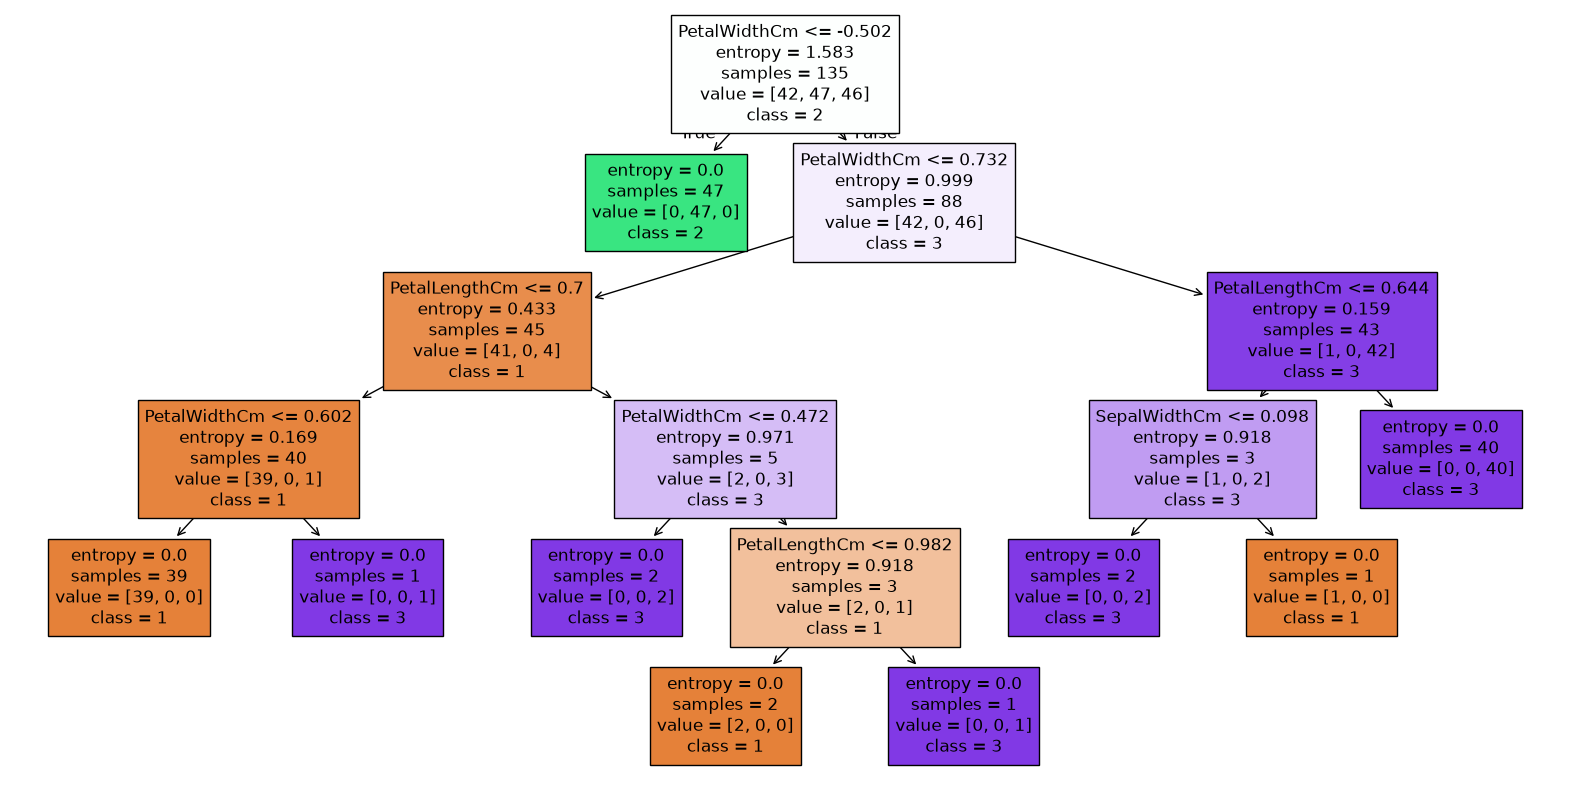

In [47]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

tree.plot_tree(
    classifier,
    feature_names=[
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ],
    class_names=["1", "2", "3"],
    filled=True
)

plt.show()

---

##### **Gini**

In [48]:
from sklearn.tree import DecisionTreeClassifier

classifier_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=0
)

classifier_gini.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [49]:
y_pred_gini = classifier_gini.predict(X_test)

print("Predicted:")
print(y_pred_gini)

print("\nActual:")
print(y_test.values)

Predicted:
[2 0 1 2 1 2 1 0 0 0 2 0 0 0 0]

Actual:
[2 0 1 2 1 2 1 0 0 0 2 0 0 0 0]


In [50]:
from sklearn.metrics import accuracy_score

accuracy_gini = accuracy_score(y_test, y_pred_gini)

print("Gini Accuracy:", accuracy_gini)
print("Gini Accuracy: {:.2f}%".format(accuracy_gini * 100))

Gini Accuracy: 1.0
Gini Accuracy: 100.00%


In [51]:
from sklearn.metrics import confusion_matrix

cm_gini = confusion_matrix(y_test, y_pred_gini)

print("Gini Confusion Matrix:")
print(cm_gini)

Gini Confusion Matrix:
[[8 0 0]
 [0 3 0]
 [0 0 4]]


In [52]:
from sklearn.metrics import classification_report

print("Gini Classification Report:")
print(classification_report(y_test, y_pred_gini))

Gini Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         4

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



In [53]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

new_flower_scaled = sc.transform(new_flower)

prediction_gini = classifier_gini.predict(new_flower_scaled)

print("Predicted Species:", prediction_gini[0])

Predicted Species: 1


c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


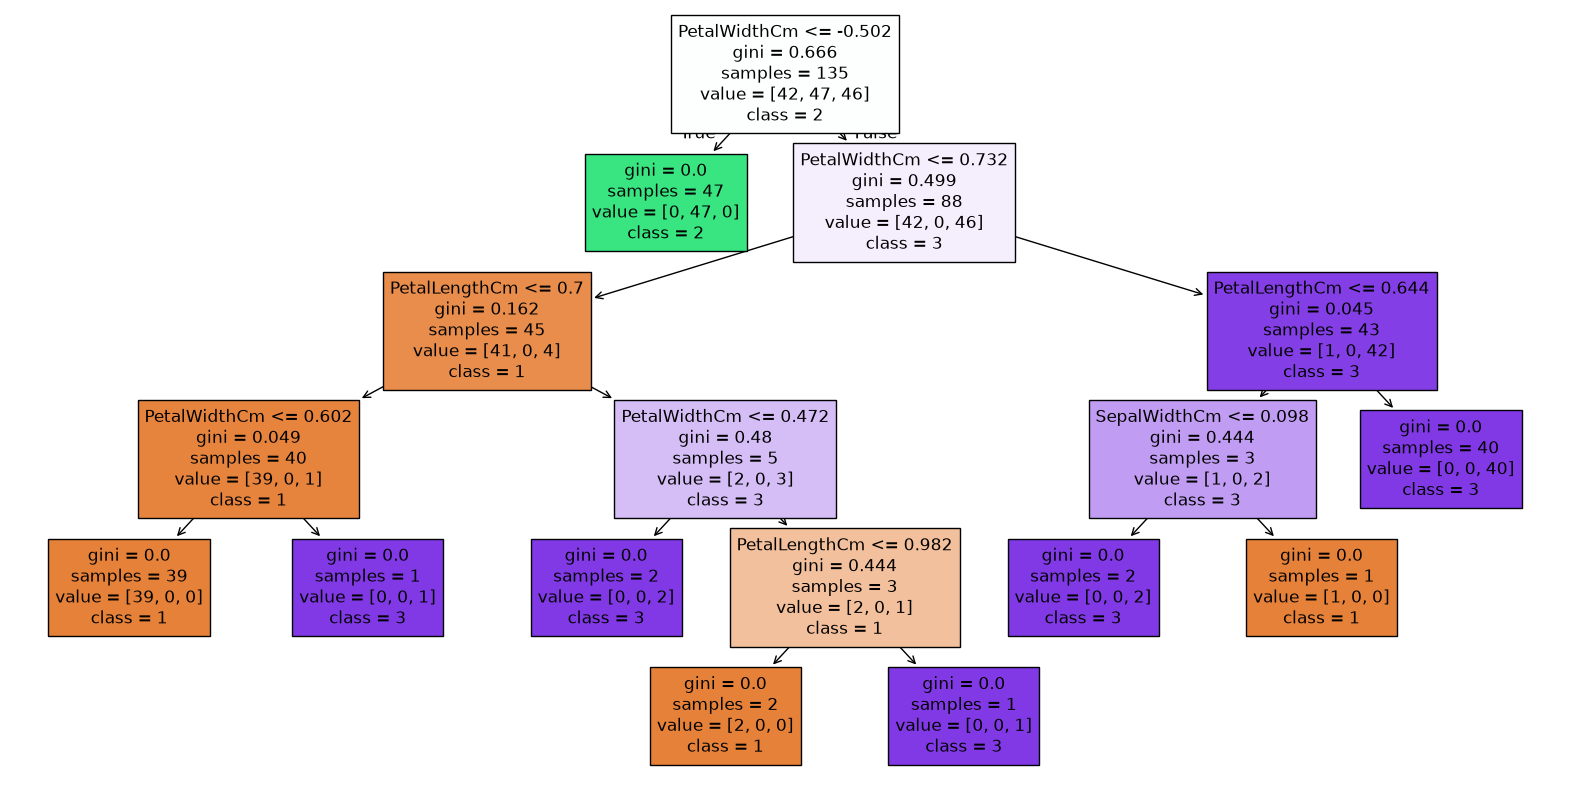

In [54]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

tree.plot_tree(
    classifier_gini,
    feature_names=[
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ],
    class_names=["1", "2", "3"],
    filled=True
)

plt.show()

---

**Entropy:** The Decision Tree using the Entropy criterion achieved a maximum accuracy of 100% with a test size of 10%.

**Gini:** The Decision Tree using the Gini criterion also achieved a maximum accuracy of 100% with a test size of 10%.

**Both criteria produced the same maximum accuracy on this dataset with the selected train-test split.**

---

### **Decision Tree Classifier for Diabetes Dataset**

##### **Data PreProcessing**

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [56]:
df = pd.read_csv(r"D:\261100670031\AML_LAB\LAB\Data\diabetes.csv" )
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [57]:
print(df.info())
print()
print(df.head())
print()
print(df.shape)
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("\nDuplicate values:")
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183      

In [58]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

y:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=0
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


In [60]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

---

##### **Entropy**

In [61]:
from sklearn.tree import DecisionTreeClassifier

classifier_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)

classifier_entropy.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [62]:
y_pred_entropy = classifier_entropy.predict(X_test)

print("Predicted values:")
print(y_pred_entropy)

print("\nActual values:")
print(y_test.values)

Predicted values:
[1 0 0 1 0 0 1 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1
 0 1 1 1 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 1 0 0 0 1 0 1 1 1 0 0 1 0 0 0 0 1
 1 1 0 0 0 1 1 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 1 1 1 0 0 0 0 1 1 0 1 0 1 0
 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 1 1 1 1 0 0 0 1 0 0 1 0 0 0
 0 1 0 0 0 0]

Actual values:
[1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
 0 0 0 0 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 0 1 1 1 1 0 0 1 1 1 1 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 0 0 1 0
 1 1 1 1 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 0
 0 1 0 1 0 0]


In [63]:
from sklearn.metrics import accuracy_score

accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

print("Entropy Accuracy:", accuracy_entropy)
print("Entropy Accuracy: {:.2f}%".format(accuracy_entropy * 100))

Entropy Accuracy: 0.7077922077922078
Entropy Accuracy: 70.78%


In [64]:
from sklearn.metrics import confusion_matrix

cm_entropy = confusion_matrix(y_test, y_pred_entropy)

print("Entropy Confusion Matrix:")
print(cm_entropy)

Entropy Confusion Matrix:
[[79 28]
 [17 30]]


In [65]:
from sklearn.metrics import classification_report

print("Entropy Classification Report:")
print(classification_report(y_test, y_pred_entropy))

Entropy Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       107
           1       0.52      0.64      0.57        47

    accuracy                           0.71       154
   macro avg       0.67      0.69      0.67       154
weighted avg       0.73      0.71      0.72       154



In [66]:
new_patient = [[
    1,       # Pregnancies
    120,     # Glucose
    70,      # BloodPressure
    25,      # SkinThickness
    80,      # Insulin
    30.0,    # BMI
    0.5,     # DiabetesPedigreeFunction
    30       # Age
]]

new_patient_scaled = sc.transform(new_patient)

prediction = classifier_entropy.predict(new_patient_scaled)

print("Predicted Outcome:", prediction[0])

Predicted Outcome: 0


c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


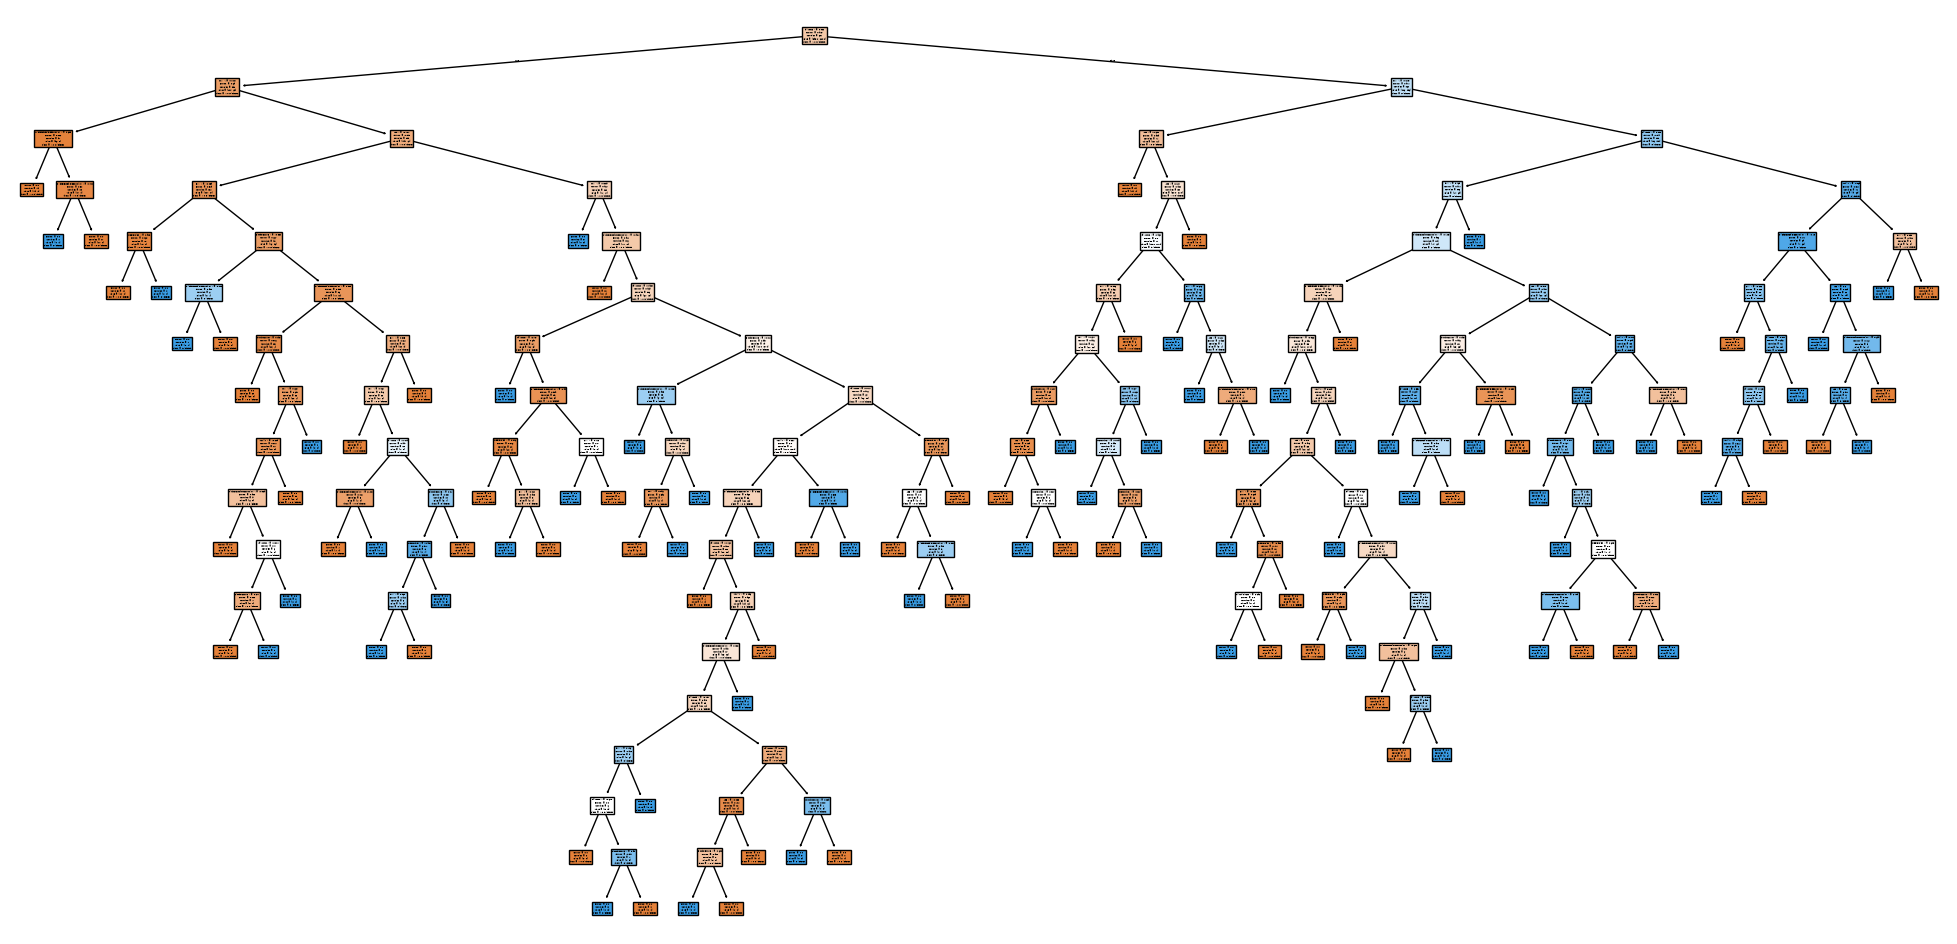

In [67]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 12))

tree.plot_tree(
    classifier_entropy,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True
)

plt.show()

---

##### **Gini**

In [68]:
from sklearn.tree import DecisionTreeClassifier

classifier_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=0
)

classifier_gini.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [69]:
y_pred_gini = classifier_gini.predict(X_test)

print("Predicted values:")
print(y_pred_gini)

print("\nActual values:")
print(y_test.values)

Predicted values:
[1 0 0 1 0 0 1 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0
 0 1 1 1 0 0 1 0 0 0 0 1 0 1 1 1 1 0 0 0 1 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 1
 1 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0
 1 1 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 1 0 0 1 0 0 0
 0 0 0 0 0 0]

Actual values:
[1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
 0 0 0 0 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 0 1 1 1 1 0 0 1 1 1 1 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 0 0 1 0
 1 1 1 1 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 0
 0 1 0 1 0 0]


In [70]:
from sklearn.metrics import accuracy_score

accuracy_gini = accuracy_score(y_test, y_pred_gini)

print("Gini Accuracy:", accuracy_gini)
print("Gini Accuracy: {:.2f}%".format(accuracy_gini * 100))

Gini Accuracy: 0.7662337662337663
Gini Accuracy: 76.62%


In [71]:
from sklearn.metrics import confusion_matrix

cm_gini = confusion_matrix(y_test, y_pred_gini)

print("Gini Confusion Matrix:")
print(cm_gini)

Gini Confusion Matrix:
[[87 20]
 [16 31]]


In [72]:
from sklearn.metrics import classification_report

print("Gini Classification Report:")
print(classification_report(y_test, y_pred_gini))

Gini Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.83       107
           1       0.61      0.66      0.63        47

    accuracy                           0.77       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.77      0.77      0.77       154



In [73]:
new_patient = [[
    1,
    120,
    70,
    25,
    80,
    30.0,
    0.5,
    30
]]

new_patient_scaled = sc.transform(new_patient)

prediction_gini = classifier_gini.predict(new_patient_scaled)

print("Predicted Outcome:", prediction_gini[0])

Predicted Outcome: 1


c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


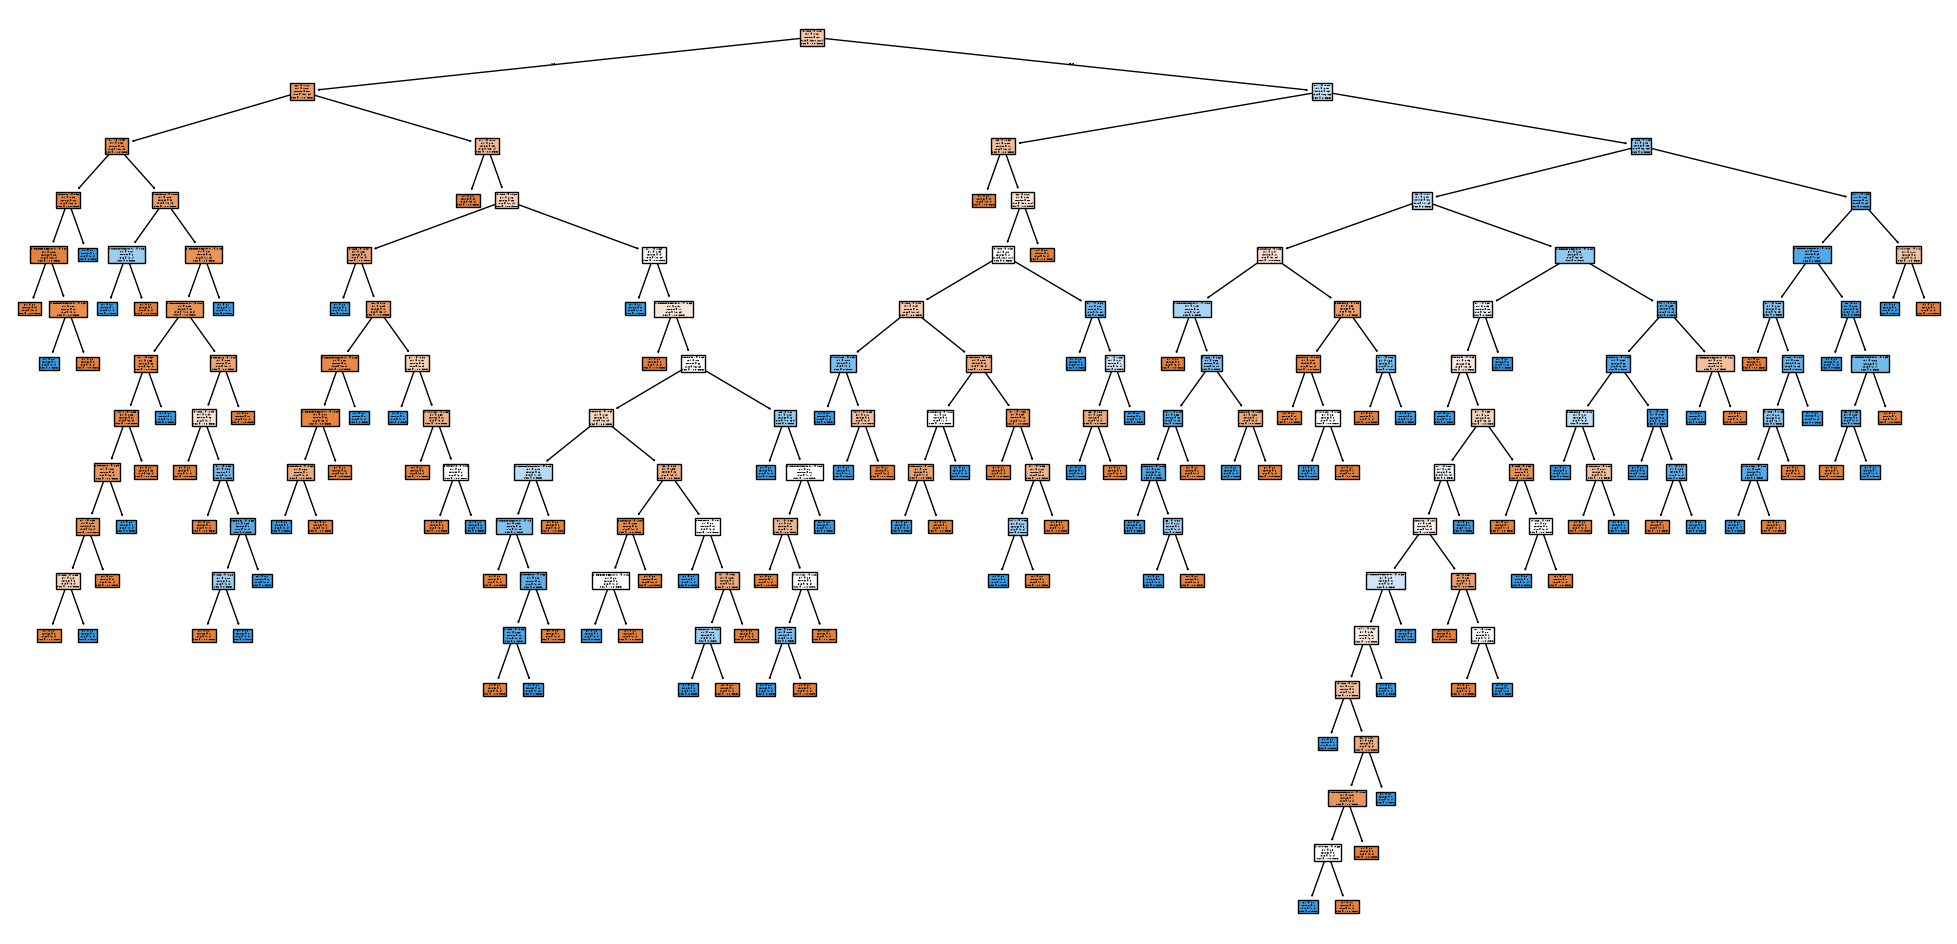

In [74]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 12))

tree.plot_tree(
    classifier_gini,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True
)

plt.show()

---